In [67]:
from spotify_kdtree import KDTree
import json
import pandas as pd
import matplotlib.pyplot as plt
import time
import operator


# using our json playlist data, this function loads file and retrieves playlistand returns playlist dictionary
# 'i' is the playlist number in the data set, range = 1-999
def getPlaylist_json(i):
    with open("mpd.slice.0-999.json", "r") as f:
        data = json.load(f)
        playlists = data["playlists"]
        playlist = playlists[i]
        # print("Playlist name:", playlist["name"])
        # for track in playlist["tracks"]:
        #     print("-", track["track_name"], "by", track["artist_name"])
        #     print()
    return playlist


# this code tracks and plots runtime of k-nearest function of the newer KDTree implementation
def runtimeTestNew():
    embedded_df = pd.read_csv("embedding.csv")
    kd = KDTree(embedded_df.to_numpy())

    runtimes = []
    song_counts = []

    # find 1 nearest neighbor, 2, 3, 4...20 and time how long each k_nearest() call takes
    for count in range(1, 26): 
        # for j in range(count):
        fts = embedded_df.iloc[40].to_numpy()
        start_time = time.time()
        kd.k_nearest(fts, count)
        end_time = time.time()

        runtimes.append(end_time - start_time)
        song_counts.append(count)

    # singular plot runtime vs number of songs
    # plt.figure(figsize=(8, 5))
    # plt.plot(song_counts, runtimes)
    # plt.title("Runtime vs Number of Songs Queried")
    # plt.xlabel("Number of Songs Queried")
    # plt.ylabel("Total Runtime (seconds)")
    # plt.grid(True)
    # plt.show()



    return runtimes, song_counts

# this code tracks and plots runtime of k-nearest function of the older KDTree implementation
def runtimeTestOld():
    embedded_df = pd.read_csv("embedding.csv")
    kd = KDTree(embedded_df.to_numpy())

    runtimes = []
    song_counts = []

    # find 1 nearest neighbor, 2, 3, 4...20 and time how long each k_nearest() call takes
    for count in range(1, 26): 
        # for j in range(count):
        fts = embedded_df.iloc[40].to_numpy()
        start_time = time.time()
        kd.k_nearest_old(fts, count)
        end_time = time.time()

        runtimes.append(end_time - start_time)
        song_counts.append(count)

    # singular plot runtime vs number of songs
    # plt.figure(figsize=(8, 5))
    # plt.plot(song_counts, runtimes)
    # plt.title("Runtime vs Number of Songs Queried")
    # plt.xlabel("Number of Songs Queried")
    # plt.ylabel("Total Runtime (seconds)")
    # plt.grid(True)
    # plt.show()

    return runtimes, song_counts


def runtimeTest():
    runtime1, song_counts1 = runtimeTestOld()
    runtime2, song_counts2 = runtimeTestNew()

    
    plt.plot(song_counts1, runtime1, label='Old Version', marker='o')
    plt.plot(song_counts2, runtime2, label='New Version', marker='s')

    plt.title("Runtime vs Number of Songs Queried (Old vs New)")
    plt.xlabel("Number of Songs Queried")
    plt.ylabel("Total Runtime (seconds)")
    plt.legend()
    plt.grid(True)
    plt.show()



# plots how many time the recommended song is seen in a playlist from songs of the tests playlist
def qualityTest(trials):

    song_num = []
    edges_num = []

    # loops through playlists in json file
    for i in range(trials):
        
        total_loc = [0] * 13
        playlist = getPlaylist_json(i)
        test_set = playlist['tracks']
        test_size = len(test_set)
        if test_size == 0:
            print("playlist was too short")
            continue
        embed_df = pd.read_csv("embedding.csv")
    
        id_list = []
            
        # for every song in our test set grab the track_id and put on a list
        for song in test_set:
            id_list.append(song['track_uri'].split(':')[-1])


        for track_id in id_list:
            # go into df and grab row as list
            row = embed_df[embed_df['track_id'] == track_id]
            if not row.empty:
                location = row.iloc[0, 1:].tolist()
                
            
            if len(location) == 0:
                # this shouldn't happen since all embedded songs
                print(f"Warning: no match found for track_id {track_id}")
                # skip this track if not found
                continue  

            
                        
            # add to cumulitive list
            for s in range(len(location)):
                total_loc[s] += location[s]
            
            
        # average location 
        avg_loc = [0]*13
        for j in range(len(total_loc)):
            avg_loc[j] = total_loc[j] / test_size
        
        kd = KDTree(embed_df.to_numpy())

        avg_loc = [float(x) for x in avg_loc]
        avg_loc.insert(0, 'test')
        

        nearest_list = kd.k_nearest_old(avg_loc, 5)
        print()
        print(nearest_list, "is a nearby value to our average song point")
        print()

        network = pd.read_csv("edges(in).csv")

        # loop through ids in songs recs and if it is found in the csv then add the connections
        total_conns = 0
        for song_id in nearest_list:
            match = network[(network['track1'] == song_id) | (network['track2'] == song_id)]
            match = match[(match['track1'].isin(id_list)) | (match['track2'].isin(id_list))]
            total_conns += match['weight'].sum()
        
        song_num.append(test_size)
        edges_num.append(total_conns)
    
    # zipping together lists
    zipped = list(zip(song_num, edges_num)) 
    # sorting them
    res = sorted(zipped, key=operator.itemgetter(0))  
    # unzipped is a list of two lists song_num, edges_num)
    unzipped = [list(t) for t in zip(*res)] 
    song_num = unzipped[0]
    edges_num = unzipped[1]
    print("connections: ", total_conns)
    print(song_num)
    print(edges_num)

    plt.figure(figsize=(10, 7))
    plt.scatter(song_num, edges_num)
    plt.title("Playlist Connections vs Number of Songs Queried")
    plt.xlabel("Number of Songs")
    plt.ylabel("Times the Recommend Songs Appeared on Playlists with the Test Songs")
    plt.grid(True)
    plt.show()


# gets "n" number of song reccommendations from the "playlist" dictionary
# returns reccomended song names
def getRec(n, playlist):

    # data set of songs
    with open("mpd.slice.0-999.json", "r") as f:
        data = json.load(f)
    allSongs_df = pd.json_normalize(data["playlists"], record_path="tracks")


    total_loc = [0] * 13
    test_set = playlist['tracks']
    test_size = len(test_set)
    if test_size == 0:
        print("playlist was too short")
        return
    embed_df = pd.read_csv("embedding.csv")
    id_list = []
        
    # for every song in our test set grab the track_id and put on a list
    for song in test_set:
        id_list.append(song['track_uri'].split(':')[-1])


    for track_id in id_list:
        # go into df and grab row as list
        row = embed_df[embed_df['track_id'] == track_id]
        if not row.empty:
            location = row.iloc[0, 1:].tolist()
        if len(location) == 0:
            # this shouldn't happen since all embedded songs
            print(f"Warning: no match found for track_id {track_id}")
            # skip this track if not found
            continue  
                    
        # add to cumulitive list
        for s in range(len(location)):
            total_loc += location[s]
            
            
    # average location 
    avg_loc = [0]*13
    for j in range(len(total_loc)):
        avg_loc[j] = total_loc[j] / test_size
    
    kd = KDTree(embed_df.to_numpy())

    avg_loc = [float(x) for x in avg_loc]
    avg_loc.insert(0, 'test')
        

    nearest_list = kd.k_nearest(avg_loc, n)
    print("Playlist name:", playlist["name"])
    for track in playlist["tracks"]:
        print("-", track["track_name"], "by", track["artist_name"])
    
    print()
    print("We think you might like")
    count = 1
    for song_id in nearest_list:
        track_info = allSongs_df[allSongs_df["track_uri"].str.split(":").str[-1] == song_id]
    
        print(f"{count}. {track_info['track_name'].iloc[0]} by {track_info['artist_name'].iloc[0]}")
        count += 1



In [ ]:
# The run time test plots run time in seconds vs the amount k_nearest() asked for.
# This experiment is ran using one random song in the data set and an increasing k-neighbors.
# The old version is our first implementation of the KD Tree where we had to recurse the tree
# every time we wanted a new song recommendation. The new version of KD Tree now implements an
# internal heap that allows us to get the k_nearest neighbors much faster, as shown by the graph
# below

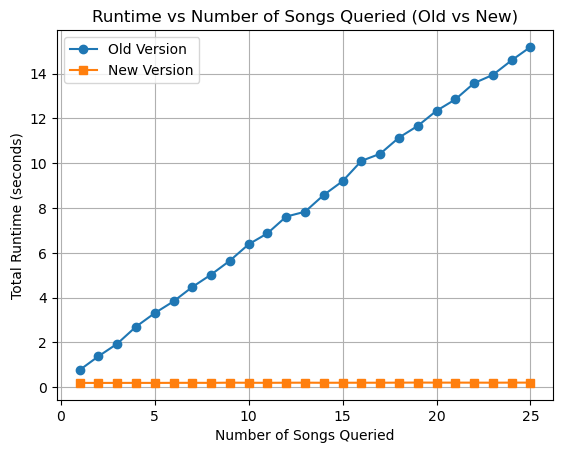

In [14]:
runtimeTest()

In [ ]:
# The quality test counts the number of times that a recommended song appears in a playlist 
# with a song from the test playlist. For each playlist in the range of the paramenter (20),
# we reccomend 5 songs and add up all of the recommended song connections. This is the plotted
# on the y-axis, while the number of songs in that playlist is plotted on the x-axis. The goal
# of this experiment is meant to illustrate how good the quality of the song rec is. If the
# recommended song is on many playlists with other songs from the original playlist then it is 
# fair to assume that the theoretical user might also want this song on their playlist. If the 
# connections are low or close to zero this could mean that the playlist contains songs that
# rarely appear on other playlists or that our embeddeding process has more room for 
# optimization, or both.

0.03585822920984094
went deeper, and check box came back False
0.03585822920984094
went deeper, and check box came back True
the real min was on the other half!
0.03398987442134356
went deeper, and check box came back True
0.03398987442134356
went deeper, and check box came back True
0.03398987442134356
went deeper, and check box came back True
0.03398987442134356
went deeper, and check box came back True
0.03398987442134356
went deeper, and check box came back True
the real min was on the other half!
0.019115122884507316
went deeper, and check box came back True
0.019115122884507316
went deeper, and check box came back True
0.019115122884507316
went deeper, and check box came back True
0.019115122884507316
went deeper, and check box came back True
0.013757436182554043
went deeper, and check box came back True
0.013757436182554043
went deeper, and check box came back True
0.013757436182554043
went deeper, and check box came back True
removing song ID 0JiVRyTJcJnmlwCZ854K4p
0.0358582292

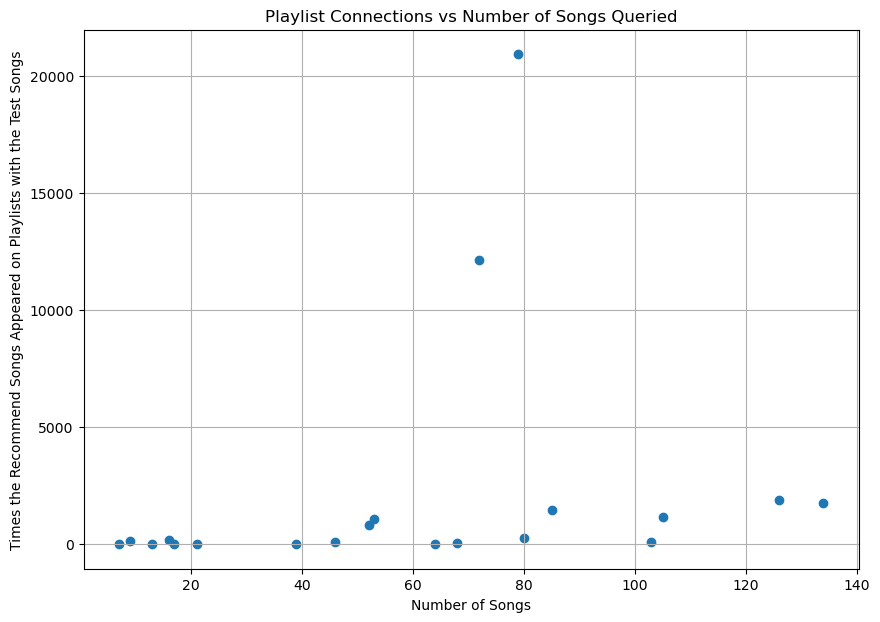

In [65]:
qualityTest(20)

In [66]:
playlist = getPlaylist_json(4)
getRec(5, playlist)

Playlist name: 90s
- Tonight, Tonight by The Smashing Pumpkins
- Wonderwall - Remastered by Oasis
- I Don't Want to Miss a Thing - From the Touchstone film, "Armageddon" by Aerosmith
- Jealousy - Remastered Single Version by Natalie Merchant
- Waterfalls by TLC
- 1979 by The Smashing Pumpkins
- Torn by Natalie Imbruglia
- Stay by Lisa Loeb & Nine Stories
- Breathe Again by Toni Braxton
- Angel by Sarah McLachlan
- Bitter Sweet Symphony by The Verve
- Runaway Train by Soul Asylum
- The Freshmen by The Verve Pipe
- White Flag by Dido
- Smooth Operator - Single Version by Sade
- Tom's Diner - 7" Version by DNA
- Only Wanna Be With You by Hootie & The Blowfish

We think you might like
1. Promises by Jhene Aiko
2. Disenchanted by My Chemical Romance
3. Raise Your Glass by P!nk
4. Hey Girl by Lady Gaga
5. Southern Hospitality (Featuring Pharrell) by Ludacris



['0JiVRyTJcJnmlwCZ854K4p', '6JG0qhINKVwiHxqN85j7RG', '6t2eIONH4Sax3R21QWiKNp', '0xl1w2q4VLojeXp4JfazPL', '7sqK6f8dHVx3Q1GjFrVyGl'] is a nearby value to our average song point


['0UAmPUdpTRq8w54B3H8TzY', '6tP1NaAIoxSTzeFgCUO66V', '6RUKPb4LETWmmr3iAEQktW', '5JkCyeCL0S3UqzlibpeDdb', '0Cvjlph1WGbwZY1PlMEtJY'] is a nearby value to our average song point


['5z9cKcr2oSPGkl0947lsky', '2cdApPfeTSJE4X0Z2rVlWz', '2BX2njwutbKutDcLVFiqUU', '6Sky6VWGUEb1zRARXKSkAQ', '16PNN9wK1LbedzcTp7y8y0'] is a nearby value to our average song point


['41KIQllu3eKuD4RdLSpzX0', '4tPFEWRuNQhibDQSGB2PVE', '3GhsBdS9ulPK3KCdwHRPhG', '5rKor0rlCbaA7j755zhnhb', '7svpAkwc6xaSxlbZ7V7JiS'] is a nearby value to our average song point


['1ZPlNanZsJSPK5h9YZZFbZ', '73Ylfpw1nyepxGaQ5R6oPA', '2tuWxZctCHB4ETgPE8rb34', '581gLYhF5OxQzgfIMGlAvu', '0jn2XqaHliEpWd04ZykIHy'] is a nearby value to our average song point


['5qi7piHIt9zwTYYBnIvfNZ', '2IuWB214OCchhPrBK8OtIR', '2jGUAB6hKlzK0pZmZpQ02g', '6ekV6MGnPTuCOnjB4VcWGc', '5BSz8sJO

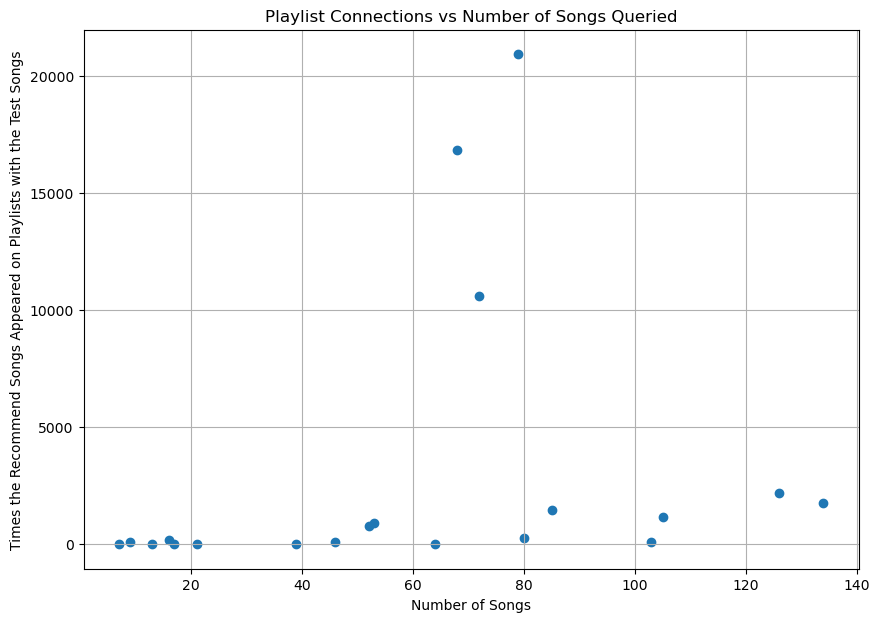

In [69]:
qualityTest(20)